---
title: CMMTE Comparisons
date: 02/2026
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

First, let's load up a csv table of with count and duration information for CMMTEs across the various regions of Antarctica, for each month of each year from 1992-2012. This table was extracted from the CMMT Excel spreadsheets, provided by Jonathan Chambers and Matthew Lazzara.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from artools.loading_utils import *
from artools.attribute_utils import *
from artools.format_utils import *
from artools.display_utils import *

/home/jovyan/antarctic_AR_dataset/notebooks/quality_assurance


In [2]:
# loading up the CMMTE data
cmmtes = pd.read_csv('../../input_data/cmmte/cmmte_regional_counts_durations.csv')
cmmtes['count'] = cmmtes.iloc[:,-12:].sum(1)

/tmp/ipykernel_263/2149630709.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cmmtes['count'] = cmmtes.iloc[:,-12:].sum(1)


In [23]:
# loading up the catalogs and doing some light preprocessing
ais_da = load_ais('../../input_data/antarctic_masks/')

full_cat = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling_storms = full_cat[full_cat.is_landfalling]

landfalling_storms['start_date'] = landfalling_storms['data_array'].apply(add_start_date, ais_da=ais_da)
landfalling_storms['end_date'] = landfalling_storms['data_array'].apply(add_end_date, ais_da=ais_da)
landfalling_storms['landfall_duration'] = landfalling_storms['data_array'].apply(compute_duration, ais_da=ais_da)
landfalling_storms['full_duration'] = landfalling_storms['data_array'].apply(compute_duration)

## Aggregate Statistics

We first compare our catalog with the CMMT event product in an aggregate sense, looking at spatial and temporal relationships in event counts and event durations.

In [65]:
yearly_cmmtes = cmmtes.groupby('Year')['count'].sum()
yearly_cmmtes = yearly_cmmtes.loc[1993:2012] 
yearly_ars = landfalling_storms.groupby(landfalling_storms['start_date'].dt.year).size()
yearly_ars = yearly_ars.loc[1993:2012]

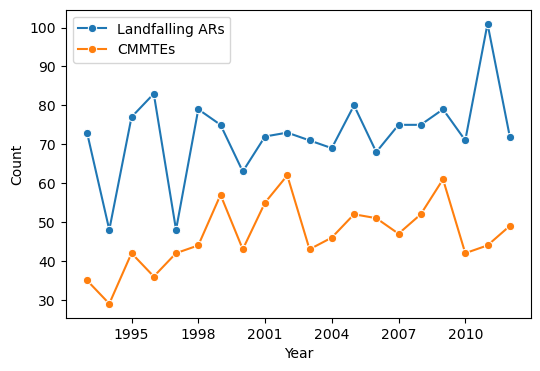

In [66]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=yearly_ars.index.astype(int), 
             y=yearly_ars.values, 
             marker='o', 
             label='Landfalling ARs')

sns.lineplot(x=yearly_cmmtes.index.astype(int), 
             y=yearly_cmmtes.values, 
             marker='o', 
             label='CMMTEs')

# Axis Labeling
plt.xlabel('Year')
plt.ylabel('Count')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


plt.legend()
plt.savefig('../../output/count_comparisons.png', dpi=300)

In [67]:
yearly_cmmtes.corr(yearly_ars)

np.float64(0.28572212843294015)

In [68]:
cmmte_differenced = yearly_cmmtes.diff(periods=1)
ars_differenced = yearly_ars.diff(periods=1)
ars_differenced.corr(cmmte_differenced)

np.float64(0.23320182633615924)

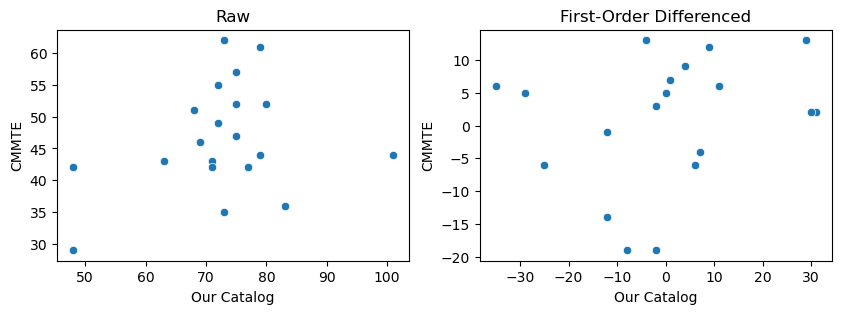

In [69]:
fig, ax = plt.subplots(ncols=2, figsize=(10,3))

ax[0].set_title('Raw')
ax[0].set_ylabel('CMMTE')
ax[0].set_xlabel('Our Catalog')
sns.scatterplot(x=yearly_ars, y=yearly_cmmtes, ax=ax[0])
ax[1].set_title('First-Order Differenced')
ax[1].set_ylabel('CMMTE')
ax[1].set_xlabel('Our Catalog')
sns.scatterplot(x=ars_differenced, y=cmmte_differenced, ax=ax[1]);

Some similar structure, but correlations are not exactly as we may hope for. I'm imagining this has something to do with how a CMMTE is defined: there is a time condition where the event must be making landfall for a certain amount of time (from [the website](https://amrdc.ssec.wisc.edu/projects/cmmt): 'An event in which a cloud mass travels from an oceanic region perpendicularly onto the continent, lasting at least 48 consecutive hours.'). I'm not sure yet if this means 48 consecutive hours of landfall, or that the storm was tracked for 48 consecutive hours and the landfalling duration was less time. I'm going to assume the latter for now.

In [70]:
landfalling_storms_longer = landfalling_storms[landfalling_storms.full_duration >= 48]
yearly_cmmtes = cmmtes.groupby('Year')['count'].sum()
yearly_cmmtes = yearly_cmmtes.loc[1993:2012] 
yearly_ars = landfalling_storms_longer.groupby(landfalling_storms_longer['start_date'].dt.year).size()
yearly_ars = yearly_ars.loc[1993:2012]

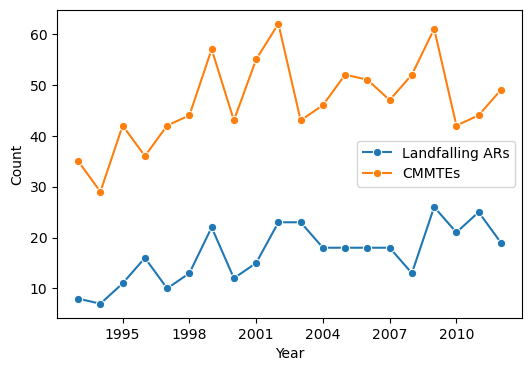

In [71]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=yearly_ars.index.astype(int), 
             y=yearly_ars.values, 
             marker='o', 
             label='Landfalling ARs')

sns.lineplot(x=yearly_cmmtes.index.astype(int), 
             y=yearly_cmmtes.values, 
             marker='o', 
             label='CMMTEs')

# Axis Labeling
plt.xlabel('Year')
plt.ylabel('Count')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


plt.legend();

In [72]:
yearly_cmmtes.corr(yearly_ars)

np.float64(0.6312494504106684)

In [73]:
cmmte_differenced = yearly_cmmtes.diff(periods=1)
ars_differenced = yearly_ars.diff(periods=1)
ars_differenced.corr(cmmte_differenced)

np.float64(0.46568904701640307)

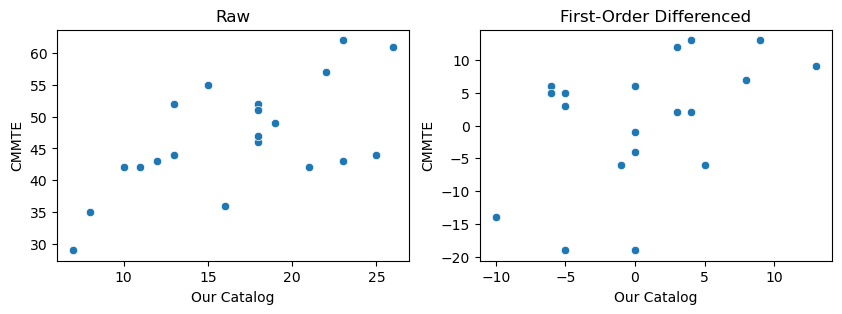

In [74]:
fig, ax = plt.subplots(ncols=2, figsize=(10,3))

ax[0].set_title('Raw')
ax[0].set_ylabel('CMMTE')
ax[0].set_xlabel('Our Catalog')
sns.scatterplot(x=yearly_ars, y=yearly_cmmtes, ax=ax[0])
ax[1].set_title('First-Order Differenced')
ax[1].set_ylabel('CMMTE')
ax[1].set_xlabel('Our Catalog')
sns.scatterplot(x=ars_differenced, y=cmmte_differenced, ax=ax[1]);

Correlation in actual counts and differences from year to year are much higher if we subset based on the length of the storms. We do have much less storms overall when subsetting in this way, however.

## Individual Event Comparisons

We also compare our products on an event-by-event basis for a particular year of events, verifying if events reported in the CMMT archive are also present in our catalog, and vice versa.

In [7]:
storms2009 = landfalling_storms[landfalling_storms.end_date.dt.year == 2009]

In [8]:
stormtime = to_stormtime_format(storms2009)

In [9]:
animation = make_movie(stormtime, '2009 Storms', '../../output/2009_storms.mp4')

Saving animation to ../../output/2009_storms.mp4...


  0%|          | 0/2920 [00:00<?, ?it/s]

In [10]:
from IPython.display import Video
Video("../../output/2009_storms.mp4", embed=True, html_attributes="controls")

In [11]:
from IPython.display import Video
Video("output/2009_storms.mp4", embed=True, html_attributes="controls")